<a href="https://colab.research.google.com/github/Uchihatt/My-Projects/blob/main/Motive_Clothing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install openpyxl

import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()   # upload Motive_Clothing_Live_Dashboard_fixed.xlsx

file_name = next(iter(uploaded.keys()))
file_name


Saving Motive_Clothing_Live_Dashboard_fixed.xlsx to Motive_Clothing_Live_Dashboard_fixed (1).xlsx


'Motive_Clothing_Live_Dashboard_fixed (1).xlsx'

In [ ]:
# Read sheets
xls = pd.ExcelFile(file_name)
xls.sheet_names


['README',
 'Branch_Master',
 'Sales_Data',
 'Control',
 'Calc',
 'Dashboard',
 'Insights']

In [ ]:
sales = pd.read_excel(file_name, sheet_name="Sales_Data")
branches = pd.read_excel(file_name, sheet_name="Branch_Master")

sales.head(), branches.head()


(        Date Week_Start   Week_End  Year Quarter  Month Month_Name  Week_Num  \
 0 2024-01-01 2024-01-01 2024-01-07  2024      Q1      1        Jan         1   
 1 2024-01-01 2024-01-01 2024-01-07  2024      Q1      1        Jan         1   
 2 2024-01-01 2024-01-01 2024-01-07  2024      Q1      1        Jan         1   
 3 2024-01-01 2024-01-01 2024-01-07  2024      Q1      1        Jan         1   
 4 2024-01-01 2024-01-01 2024-01-07  2024      Q1      1        Jan         1   
 
    Branch_ID Branch_Code  ... Discount_Pct Footfall Transactions   Units  \
 0       1001     LHR-DHA  ...       0.0382  3157.06        35.06   63.81   
 1       1001     LHR-DHA  ...       0.0208  3157.06        29.59   37.89   
 2       1001     LHR-DHA  ...       0.0270  3157.06        61.88   98.55   
 3       1001     LHR-DHA  ...       0.0303  3157.06        84.36  112.53   
 4       1001     LHR-DHA  ...       0.0287  3157.06       109.13  147.64   
 
        ASP Gross_Revenue Net_Revenue       COGS

In [ ]:
df = sales.merge(branches, on="Branch_ID", how="left")

# Fix City duplicate columns
df["City"] = df["City_y"].fillna(df["City_x"])
df = df.drop(columns=["City_x", "City_y"])

# Fix Area_Manager duplicate columns (same issue)
df["Area_Manager"] = df["Area_Manager_y"].fillna(df["Area_Manager_x"])
df = df.drop(columns=["Area_Manager_x", "Area_Manager_y"])

# Flags
df["Is_Lahore"] = (df["City"].astype(str).str.lower().str.strip() == "lahore").astype(int)
df["Is_My4"] = (df["Area_Manager"].astype(str).str.strip() == "Lahore_AM_You").astype(int)

df.head()


,Date,Week_Start,Week_End,Year,Quarter,Month,Month_Name,Week_Num,Branch_ID,Branch_Code_x,...,Branch_Name_y,Province_y,Cluster_y,Store_Format_y,Size_Index,Rent_Index,City,Area_Manager,Is_Lahore,Is_My4
0,2024-01-01,2024-01-01,2024-01-07,2024,Q1,1,Jan,1,1001,LHR-DHA,...,DHA,Punjab,Urban,Mall,1.121,1.438,Lahore,Lahore_AM_You,1,1
1,2024-01-01,2024-01-01,2024-01-07,2024,Q1,1,Jan,1,1001,LHR-DHA,...,DHA,Punjab,Urban,Mall,1.121,1.438,Lahore,Lahore_AM_You,1,1
2,2024-01-01,2024-01-01,2024-01-07,2024,Q1,1,Jan,1,1001,LHR-DHA,...,DHA,Punjab,Urban,Mall,1.121,1.438,Lahore,Lahore_AM_You,1,1
3,2024-01-01,2024-01-01,2024-01-07,2024,Q1,1,Jan,1,1001,LHR-DHA,...,DHA,Punjab,Urban,Mall,1.121,1.438,Lahore,Lahore_AM_You,1,1
4,2024-01-01,2024-01-01,2024-01-07,2024,Q1,1,Jan,1,1001,LHR-DHA,...,DHA,Punjab,Urban,Mall,1.121,1.438,Lahore,Lahore_AM_You,1,1


In [ ]:
# @title Executive snapshot KPIs (Pakistan vs Lahore vs My 4)
def kpi_view(data, label):
    out = {
        "Scope": label,
        "Revenue": data["Net_Revenue"].sum(),
        "Units": data["Units"].sum(),
        "Gross Profit": data["Gross_Profit"].sum(),
        "Gross Margin %": data["Gross_Profit"].sum() / data["Net_Revenue"].sum(),
        "Avg Discount %": data["Discount_Pct"].mean(),
        "Promo Share %": (data["Promo_Flag"].eq("Promo").mean() if "Promo_Flag" in data else np.nan)
    }
    return out

pak = df.copy()
lahore = df[df["Is_Lahore"] == 1]
my4 = df[df["Is_My4"] == 1]

kpis = pd.DataFrame([
    kpi_view(pak, "All Pakistan"),
    kpi_view(lahore, "Lahore (all branches)"),
    kpi_view(my4, "My 4 Lahore branches"),
])

kpis


,Scope,Revenue,Units,Gross Profit,Gross Margin %,Avg Discount %,Promo Share %
0,All Pakistan,5.269746e+09,1971656.11,2.717077e+09,0.515599,0.049185,0.0
1,Lahore (all branches),1.308047e+09,489242.80,6.745197e+08,0.515669,0.048868,0.0
2,My 4 Lahore branches,5.243940e+08,196205.14,2.704248e+08,0.515690,0.049194,0.0


In [ ]:
[c for c in df.columns if "discount" in c.lower()]


['Discount_Pct']

In [ ]:
[c for c in df.columns if "Area" in c or "Manager" in c]


['Area_Manager_x', 'Area_Manager_y']

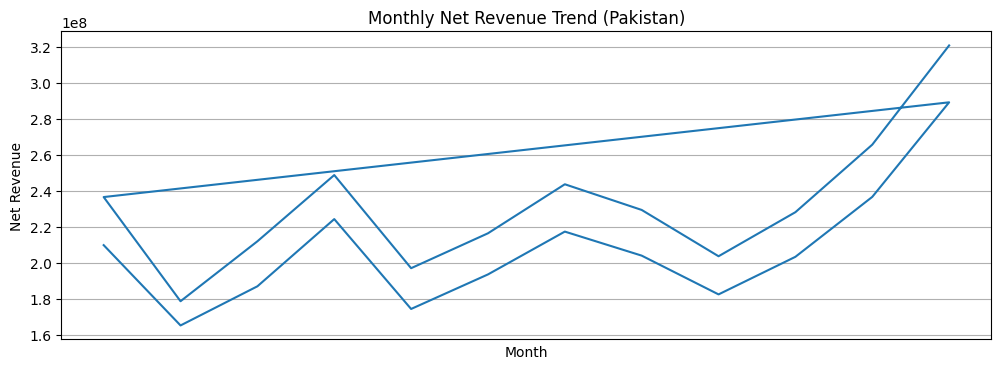

In [ ]:
# @title Monthly trend + YoY growth
monthly = (df.groupby(["Year","Month"], as_index=False)
             .agg(Net_Revenue=("Net_Revenue","sum"),
                  Gross_Profit=("Gross_Profit","sum"),
                  Units=("Units","sum"),
                  Avg_Discount=("Discount_Pct","mean")))

monthly["Gross_Margin"] = monthly["Gross_Profit"] / monthly["Net_Revenue"]

# YoY by month label (works because you have 2 years)
monthly["MonthOnly"] = pd.to_datetime(monthly["Month"]).dt.month
pivot = monthly.pivot_table(index="MonthOnly", columns="Year", values="Net_Revenue", aggfunc="sum")
pivot["YoY_Growth_%"] = (pivot[pivot.columns.max()] / pivot[pivot.columns.min()] - 1) * 100
pivot.reset_index().head()
import matplotlib.pyplot as plt

monthly_sorted = monthly.sort_values(["Year","Month"])
plt.figure(figsize=(12,4))
plt.plot(pd.to_datetime(monthly_sorted["Month"]), monthly_sorted["Net_Revenue"])
plt.title("Monthly Net Revenue Trend (Pakistan)")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.grid(True)
plt.show()



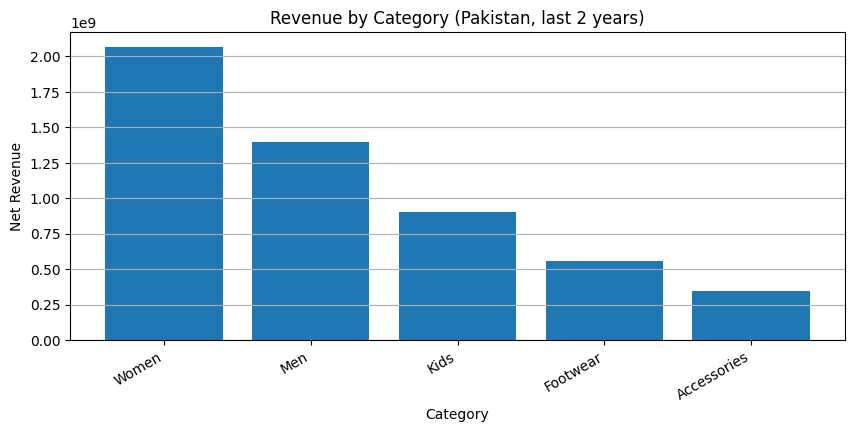

In [ ]:

# Category mix + profitability (the “story”)
cat = (df.groupby("Category", as_index=False)
         .agg(Net_Revenue=("Net_Revenue","sum"),
              Gross_Profit=("Gross_Profit","sum"),
              Units=("Units","sum"),
              Avg_Discount=("Discount_Pct","mean")))

cat["Gross_Margin"] = cat["Gross_Profit"] / cat["Net_Revenue"]
cat = cat.sort_values("Net_Revenue", ascending=False)
cat
plt.figure(figsize=(10,4))
plt.bar(cat["Category"], cat["Net_Revenue"])
plt.title("Revenue by Category (Pakistan, last 2 years)")
plt.xlabel("Category")
plt.ylabel("Net Revenue")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y")
plt.show()


In [ ]:
# @title Promo effectiveness (revenue vs margin tradeoff)
promo = (df.groupby("Promo_Flag", as_index=False)
           .agg(Net_Revenue=("Net_Revenue","sum"),
                Gross_Profit=("Gross_Profit","sum"),
                Units=("Units","sum"),
                Avg_Discount=("Discount_Pct","mean")))

promo["Gross_Margin"] = promo["Gross_Profit"] / promo["Net_Revenue"]
promo


,Promo_Flag,Net_Revenue,Gross_Profit,Units,Avg_Discount,Gross_Margin
0,No,2.412731e+09,1.244596e+09,885387.51,0.030906,0.515845
1,Yes,2.857016e+09,1.472481e+09,1086268.60,0.068503,0.515391


In [ ]:
branch_perf = (df.groupby(["Branch_ID","Branch_Name","City","Store_Format","Is_My4"], as_index=False)
  .agg(Net_Revenue=("Net_Revenue","sum"),
       Gross_Profit=("Gross_Profit","sum"),
       Units=("Units","sum"),
       Avg_Discount=("Discount_Pct","mean"),
       Promo_Share=("Promo_Flag", lambda x: (x.astype(str).str.lower() == "promo").mean())
  )
)

branch_perf["Gross_Margin"] = branch_perf["Gross_Profit"] / branch_perf["Net_Revenue"]
branch_perf["Revenue_per_Unit"] = branch_perf["Net_Revenue"] / branch_perf["Units"]

top_rev = branch_perf.sort_values("Net_Revenue", ascending=False).head(10)
bottom_margin = branch_perf.sort_values("Gross_Margin", ascending=True).head(10)

top_rev, bottom_margin


KeyError: 'Branch_Name'

In [ ]:
[c for c in df.columns if "branch" in c.lower() and "name" in c.lower()]


['Branch_Name_x', 'Branch_Name_y']

In [ ]:
# Rebuild df from scratch (prevents stale variables)
df = sales.merge(branches, on="Branch_ID", how="left", suffixes=("_sales", "_branch"))

# Fix duplicates cleanly (only if they exist)
if "City_branch" in df.columns and "City_sales" in df.columns:
    df["City"] = df["City_branch"].fillna(df["City_sales"])

if "Area_Manager_branch" in df.columns and "Area_Manager_sales" in df.columns:
    df["Area_Manager"] = df["Area_Manager_branch"].fillna(df["Area_Manager_sales"])

# Drop the suffixed versions if you want
drop_cols = [c for c in df.columns if c.endswith("_sales") or c.endswith("_branch")]
# BUT keep key fields if they are needed; safest is to NOT drop everything automatically.
# We'll just drop the two we normalized:
for c in ["City_sales","City_branch","Area_Manager_sales","Area_Manager_branch"]:
    if c in df.columns:
        df = df.drop(columns=[c])

# Flags
df["Is_Lahore"] = (df["City"].astype(str).str.lower().str.strip() == "lahore").astype(int)
df["Is_My4"] = (df["Area_Manager"].astype(str).str.strip() == "Lahore_AM_You").astype(int)

print("✅ df rebuilt. Columns now include Branch_Name?", "Branch_Name" in df.columns)


✅ df rebuilt. Columns now include Branch_Name? False


In [ ]:
df["Branch_Name"] = df["Branch_Name_branch"].fillna(df["Branch_Name_sales"])
df["Branch_Code"] = df["Branch_Code_branch"].fillna(df["Branch_Code_sales"])
df["Province"] = df["Province_branch"].fillna(df["Province_sales"])

# If you have Store_Format_branch too (you currently only show Store_Format_sales)
if "Store_Format_branch" in df.columns:
    df["Store_Format"] = df["Store_Format_branch"].fillna(df["Store_Format_sales"])
else:
    df["Store_Format"] = df["Store_Format_sales"]
to_drop = [
    "Branch_Name_sales","Branch_Name_branch",
    "Branch_Code_sales","Branch_Code_branch",
    "Province_sales","Province_branch",
    "Store_Format_sales"
]
df = df.drop(columns=[c for c in to_drop if c in df.columns])


In [ ]:
branch_perf = (df.groupby(["Branch_ID","Branch_Name","City","Store_Format","Is_My4"], as_index=False)
  .agg(Net_Revenue=("Net_Revenue","sum"),
       Gross_Profit=("Gross_Profit","sum"),
       Units=("Units","sum"),
       Avg_Discount=("Discount_Pct","mean"),
       Promo_Share=("Promo_Flag", lambda x: (x.astype(str).str.lower() == "promo").mean()))
)

branch_perf["Gross_Margin"] = branch_perf["Gross_Profit"] / branch_perf["Net_Revenue"]
branch_perf["Revenue_per_Unit"] = branch_perf["Net_Revenue"] / branch_perf["Units"]

top_rev = branch_perf.sort_values("Net_Revenue", ascending=False).head(10)
bottom_margin = branch_perf.sort_values("Gross_Margin", ascending=True).head(10)

top_rev, bottom_margin


(    Branch_ID        Branch_Name     City Store_Format  Is_My4   Net_Revenue  \
 16       1017   Karachi Branch 7  Karachi         Mall       0  1.702578e+08   
 17       1018   Karachi Branch 8  Karachi         Mall       0  1.671644e+08   
 8        1009    Lahore Branch 9   Lahore         Mall       0  1.593462e+08   
 3        1004       EmporiumMall   Lahore         Mall       1  1.590239e+08   
 11       1012   Karachi Branch 2  Karachi         Mall       0  1.518391e+08   
 4        1005    Lahore Branch 5   Lahore         Mall       0  1.500880e+08   
 13       1014   Karachi Branch 4  Karachi   HighStreet       0  1.499176e+08   
 19       1020  Karachi Branch 10  Karachi         Mall       0  1.451934e+08   
 10       1011   Karachi Branch 1  Karachi   HighStreet       0  1.404643e+08   
 6        1007    Lahore Branch 7   Lahore         Mall       0  1.376547e+08   
 
     Gross_Profit     Units  Avg_Discount  Promo_Share  Gross_Margin  \
 16   87774103.52  63686.92      0.

In [ ]:
branch_perf[branch_perf["Is_My4"]==1].sort_values("Net_Revenue", ascending=False)


,Branch_ID,Branch_Name,City,Store_Format,Is_My4,Net_Revenue,Gross_Profit,Units,Avg_Discount,Promo_Share,Gross_Margin,Revenue_per_Unit
3,1004,EmporiumMall,Lahore,Mall,1,1.590239e+08,81972495.59,59307.91,0.048967,0.0,0.515473,2681.326583
0,1001,DHA,Lahore,Mall,1,1.366622e+08,70519994.03,51214.82,0.049840,0.0,0.516017,2668.410828
1,1002,Gulberg,Lahore,HighStreet,1,1.178963e+08,60785158.66,44240.20,0.048752,0.0,0.515581,2664.913830
2,1003,JoharTown,Lahore,HighStreet,1,1.108117e+08,57147170.77,41442.21,0.049218,0.0,0.515714,2673.883846


In [ ]:
insights = []

# 1) Best category by margin
best_margin_cat = cat.sort_values("Gross_Margin", ascending=False).iloc[0]
insights.append(f"Highest margin category is {best_margin_cat['Category']} (GM {best_margin_cat['Gross_Margin']:.1%}) — push attach/bundles to lift overall GM.")

# 2) Promo effect
if "Promo" in promo["Promo_Flag"].values and "No Promo" in promo["Promo_Flag"].values:
    p = promo.set_index("Promo_Flag")
    gm_drop = p.loc["Promo","Gross_Margin"] - p.loc["No Promo","Gross_Margin"]
    insights.append(f"Promo weeks change gross margin by {gm_drop:.1%} vs non-promo. Consider narrowing promos to slow-moving SKUs and using bundles to protect margin.")

# 3) Your 4 branches vs Lahore
my4_kpi = kpi_view(my4, "My4")
lah_kpi = kpi_view(lahore, "Lahore")
insights.append(f"My 4 branches GM is {my4_kpi['Gross Margin %']:.1%} vs Lahore {lah_kpi['Gross Margin %']:.1%}. Focus: discount discipline + category mix.")

# 4) Lowest margin branches (actions)
low = branch_perf.sort_values("Gross_Margin").head(3)
insights.append("Lowest margin branches to investigate (pricing/discount leakage): " +
                ", ".join(low["Branch_Name"].tolist()) + ".")

for i in insights:
    print("•", i)


• Highest margin category is Accessories (GM 64.0%) — push attach/bundles to lift overall GM.
• My 4 branches GM is 51.6% vs Lahore 51.6%. Focus: discount discipline + category mix.
• Lowest margin branches to investigate (pricing/discount leakage): Sukkur Branch 2, Sukkur Branch 1, Hyderabad Branch 1.


In [ ]:
with pd.ExcelWriter("motive_analysis_outputs.xlsx") as writer:
    kpis.to_excel(writer, index=False, sheet_name="KPIs")
    monthly.to_excel(writer, index=False, sheet_name="Monthly")
    cat.to_excel(writer, index=False, sheet_name="Category")
    promo.to_excel(writer, index=False, sheet_name="Promo")
    branch_perf.to_excel(writer, index=False, sheet_name="Branch_Perf")

files.download("motive_analysis_outputs.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df["Week_Start"] = pd.to_datetime(df["Week_Start"])
df["MonthStart"] = df["Week_Start"].dt.to_period("M").dt.to_timestamp()


In [ ]:
def scope_df(scope="pakistan"):
    if scope == "my4":
        return df[df["Is_My4"]==1].copy()
    if scope == "lahore":
        return df[df["Is_Lahore"]==1].copy()
    return df.copy()


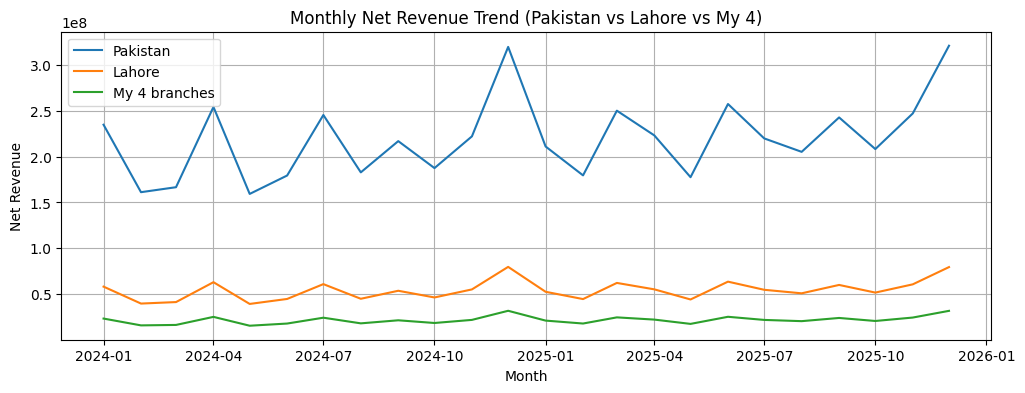

In [ ]:
def monthly_series(d):
    m = d.groupby("MonthStart", as_index=False).agg(Net_Revenue=("Net_Revenue","sum"))
    return m.sort_values("MonthStart")

pak_m = monthly_series(scope_df("pakistan"))
lah_m = monthly_series(scope_df("lahore"))
my4_m = monthly_series(scope_df("my4"))

plt.figure(figsize=(12,4))
plt.plot(pak_m["MonthStart"], pak_m["Net_Revenue"], label="Pakistan")
plt.plot(lah_m["MonthStart"], lah_m["Net_Revenue"], label="Lahore")
plt.plot(my4_m["MonthStart"], my4_m["Net_Revenue"], label="My 4 branches")
plt.title("Monthly Net Revenue Trend (Pakistan vs Lahore vs My 4)")
plt.xlabel("Month"); plt.ylabel("Net Revenue"); plt.grid(True); plt.legend()
plt.show()


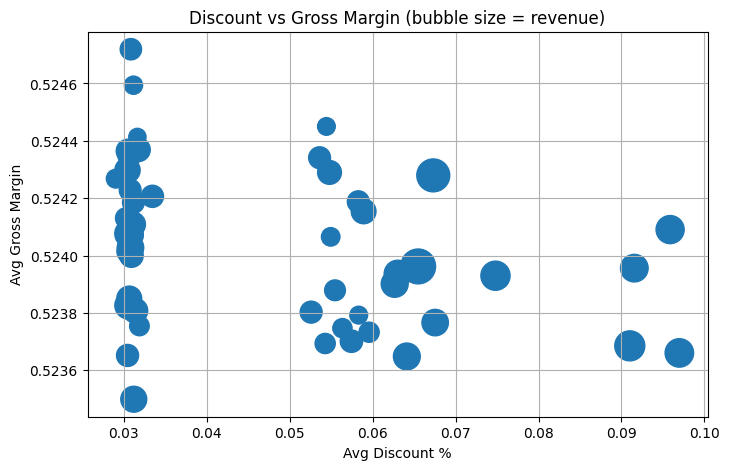

In [ ]:
# @title Promo efficiency: Discount vs Margin scatter (find “bad discounts”)
d = scope_df("pakistan").groupby(["MonthStart","Promo_Flag"], as_index=False).agg(
    Discount_Pct=("Discount_Pct","mean"),
    Gross_Margin=("Gross_Margin","mean"),
    Net_Revenue=("Net_Revenue","sum")
)

plt.figure(figsize=(8,5))
plt.scatter(d["Discount_Pct"], d["Gross_Margin"], s=(d["Net_Revenue"]/d["Net_Revenue"].max())*600 + 30)
plt.title("Discount vs Gross Margin (bubble size = revenue)")
plt.xlabel("Avg Discount %"); plt.ylabel("Avg Gross Margin")
plt.grid(True)
plt.show()


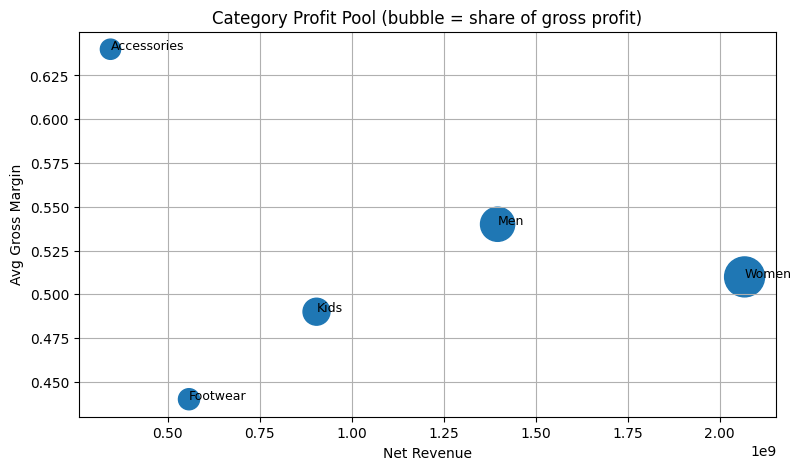

In [ ]:
# @title Categorical Comparison of Profit Pool
cat = scope_df("pakistan").groupby("Category", as_index=False).agg(
    Net_Revenue=("Net_Revenue","sum"),
    Gross_Profit=("Gross_Profit","sum"),
    Gross_Margin=("Gross_Margin","mean"),
    Discount_Pct=("Discount_Pct","mean"),
    Units=("Units","sum")
)
cat["Profit_Share"] = cat["Gross_Profit"] / cat["Gross_Profit"].sum()

plt.figure(figsize=(9,5))
plt.scatter(cat["Net_Revenue"], cat["Gross_Margin"], s=cat["Profit_Share"]*2000 + 50)
for _, r in cat.iterrows():
    plt.text(r["Net_Revenue"], r["Gross_Margin"], r["Category"], fontsize=9)
plt.title("Category Profit Pool (bubble = share of gross profit)")
plt.xlabel("Net Revenue"); plt.ylabel("Avg Gross Margin")
plt.grid(True)
plt.show()


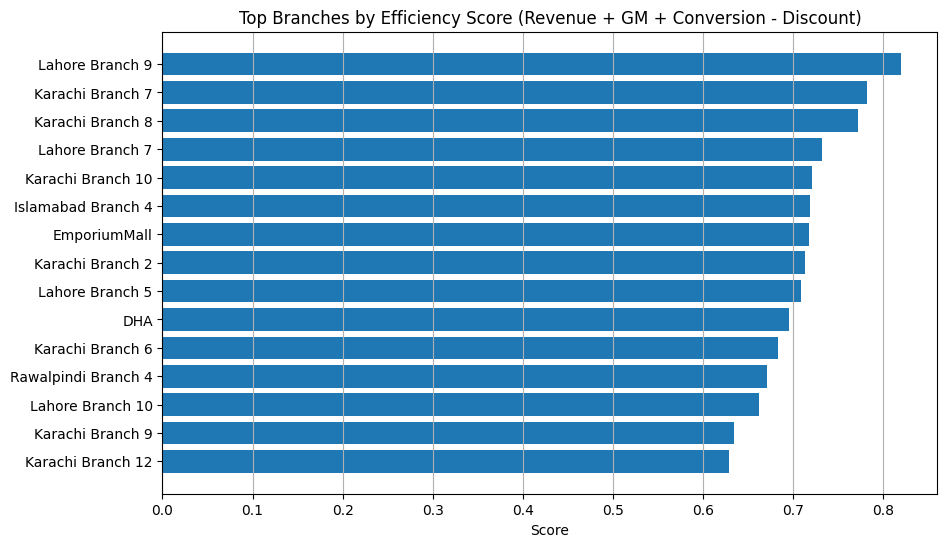

In [ ]:
# @title Top Branches By Efficiency Score
bp = scope_df("pakistan").groupby(["Branch_ID","Branch_Name","City"], as_index=False).agg(
    Net_Revenue=("Net_Revenue","sum"),
    Gross_Margin=("Gross_Margin","mean"),
    Discount_Pct=("Discount_Pct","mean"),
    Footfall=("Footfall","sum"),
    Transactions=("Transactions","sum")
)
bp["Conversion"] = bp["Transactions"] / bp["Footfall"].replace(0, np.nan)

# Normalize metrics 0-1 for scoring
def minmax(s):
    return (s - s.min())/(s.max()-s.min()) if s.max()!=s.min() else 0.5

bp["Score"] = (
    0.35*minmax(bp["Net_Revenue"]) +
    0.25*minmax(bp["Gross_Margin"]) +
    0.25*minmax(bp["Conversion"].fillna(0)) +
    0.15*(1-minmax(bp["Discount_Pct"]))
)

top = bp.sort_values("Score", ascending=False).head(15).sort_values("Score")
plt.figure(figsize=(10,6))
plt.barh(top["Branch_Name"], top["Score"])
plt.title("Top Branches by Efficiency Score (Revenue + GM + Conversion - Discount)")
plt.xlabel("Score"); plt.grid(True, axis="x")
plt.show()



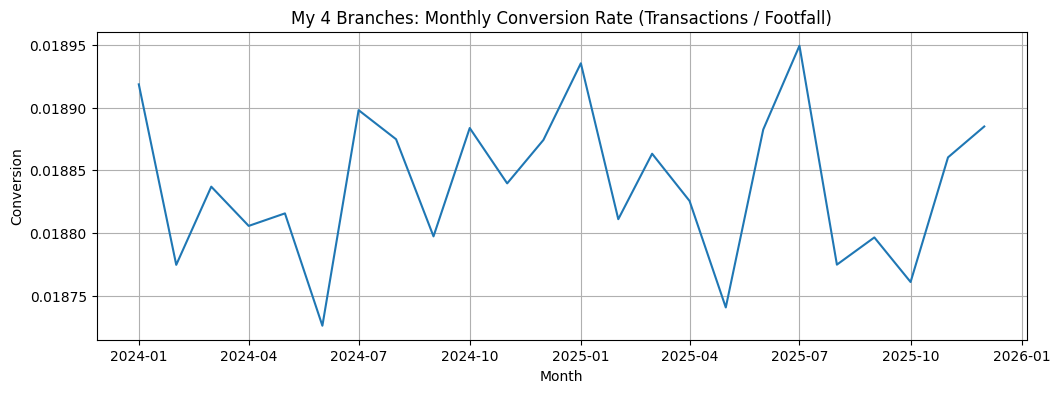

In [ ]:
d = scope_df("my4").groupby("MonthStart", as_index=False).agg(
    Footfall=("Footfall","sum"),
    Transactions=("Transactions","sum"),
    Net_Revenue=("Net_Revenue","sum")
)
d["Conversion"] = d["Transactions"]/d["Footfall"].replace(0,np.nan)

plt.figure(figsize=(12,4))
plt.plot(d["MonthStart"], d["Conversion"])
plt.title("My 4 Branches: Monthly Conversion Rate (Transactions / Footfall)")
plt.xlabel("Month"); plt.ylabel("Conversion"); plt.grid(True)
plt.show()


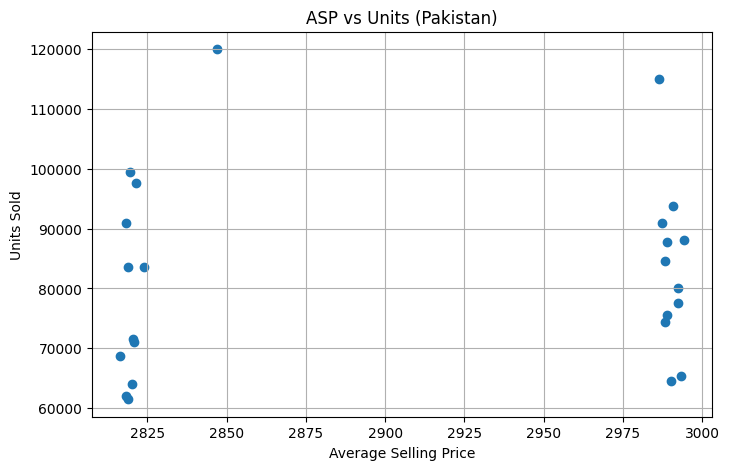

In [ ]:
asp = scope_df("pakistan").groupby("MonthStart", as_index=False).agg(
    ASP=("ASP","mean"),
    Units=("Units","sum")
)

plt.figure(figsize=(8,5))
plt.scatter(asp["ASP"], asp["Units"])
plt.title("ASP vs Units (Pakistan)")
plt.xlabel("Average Selling Price"); plt.ylabel("Units Sold")
plt.grid(True)
plt.show()


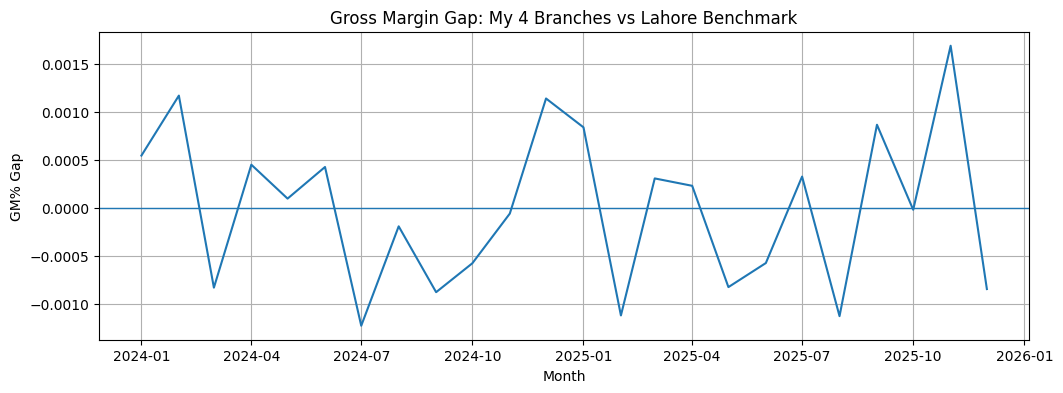

In [ ]:
my4 = scope_df("my4").groupby("MonthStart", as_index=False).agg(GM=("Gross_Profit","sum"), Rev=("Net_Revenue","sum"))
lah = scope_df("lahore").groupby("MonthStart", as_index=False).agg(GM=("Gross_Profit","sum"), Rev=("Net_Revenue","sum"))

my4["GM%"] = my4["GM"]/my4["Rev"]
lah["GM%"] = lah["GM"]/lah["Rev"]

cmp = my4.merge(lah[["MonthStart","GM%"]], on="MonthStart", how="left", suffixes=("_My4","_Lahore"))
cmp["Gap (My4 - Lahore)"] = cmp["GM%_My4"] - cmp["GM%_Lahore"]

plt.figure(figsize=(12,4))
plt.plot(cmp["MonthStart"], cmp["Gap (My4 - Lahore)"])
plt.axhline(0, linewidth=1)
plt.title("Gross Margin Gap: My 4 Branches vs Lahore Benchmark")
plt.xlabel("Month"); plt.ylabel("GM% Gap"); plt.grid(True)
plt.show()


In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# 1) Load from Excel again (edit file_name if needed)
file_name = "Motive_Clothing_Live_Dashboard_fixed.xlsx"  # <- change if your uploaded file has a different name

sales = pd.read_excel(file_name, sheet_name="Sales_Data")
branches = pd.read_excel(file_name, sheet_name="Branch_Master")

# 2) Merge
df = sales.merge(branches, on="Branch_ID", how="left", suffixes=("_sales", "_branch"))

# 3) Standardize fields (so downstream code is consistent)
# City
if "City_branch" in df.columns and "City_sales" in df.columns:
    df["City"] = df["City_branch"].fillna(df["City_sales"])
elif "City" in df.columns:
    df["City"] = df["City"]

# Area Manager
if "Area_Manager_branch" in df.columns and "Area_Manager_sales" in df.columns:
    df["Area_Manager"] = df["Area_Manager_branch"].fillna(df["Area_Manager_sales"])
elif "Area_Manager" in df.columns:
    df["Area_Manager"] = df["Area_Manager"]

# Branch name
if "Branch_Name_branch" in df.columns and "Branch_Name_sales" in df.columns:
    df["Branch_Name"] = df["Branch_Name_branch"].fillna(df["Branch_Name_sales"])
elif "Branch_Name" in df.columns:
    df["Branch_Name"] = df["Branch_Name"]

# Store format
if "Store_Format_branch" in df.columns and "Store_Format_sales" in df.columns:
    df["Store_Format"] = df["Store_Format_branch"].fillna(df["Store_Format_sales"])
elif "Store_Format_sales" in df.columns:
    df["Store_Format"] = df["Store_Format_sales"]
elif "Store_Format" in df.columns:
    df["Store_Format"] = df["Store_Format"]

# 4) Date + month
df["Week_Start"] = pd.to_datetime(df["Week_Start"])
df["MonthStart"] = df["Week_Start"].dt.to_period("M").dt.to_timestamp()

# 5) Flags
df["Is_Lahore"] = (df["City"].astype(str).str.lower().str.strip() == "lahore").astype(int)
df["Is_My4"] = (df["Area_Manager"].astype(str).str.strip() == "Lahore_AM_You").astype(int)

print("✅ df ready:", df.shape)
print("Columns check:", [c for c in ["Week_Start","MonthStart","City","Branch_Name","Store_Format","Is_Lahore","Is_My4"] if c in df.columns])


✅ df ready: (34720, 45)
Columns check: ['Week_Start', 'MonthStart', 'City', 'Branch_Name', 'Store_Format', 'Is_Lahore', 'Is_My4']


In [6]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df["Week_Start"] = pd.to_datetime(df["Week_Start"])
df["MonthStart"] = df["Week_Start"].dt.to_period("M").dt.to_timestamp()

def scope_df(scope="pakistan"):
    if scope == "my4":
        return df[df["Is_My4"]==1].copy()
    if scope == "lahore":
        return df[df["Is_Lahore"]==1].copy()
    return df.copy()


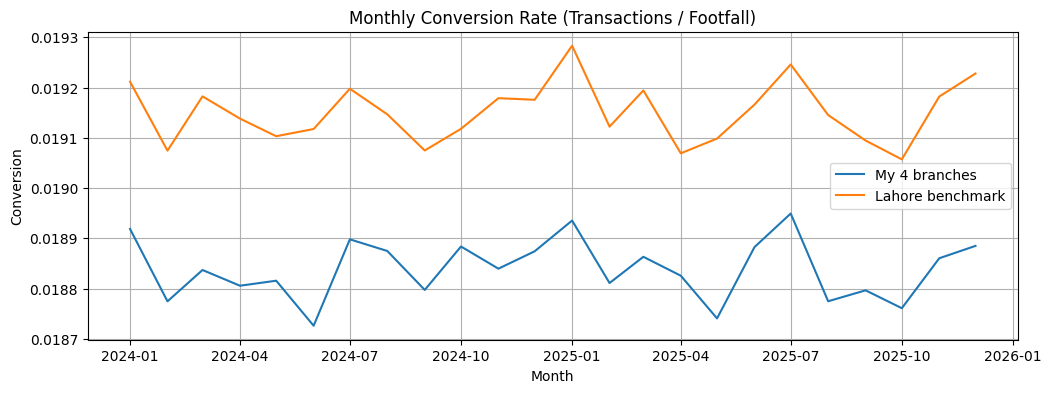

In [7]:
my4 = (scope_df("my4")
       .groupby("MonthStart", as_index=False)
       .agg(Footfall=("Footfall","sum"),
            Transactions=("Transactions","sum"),
            Net_Revenue=("Net_Revenue","sum")))

lah = (scope_df("lahore")
       .groupby("MonthStart", as_index=False)
       .agg(Footfall=("Footfall","sum"),
            Transactions=("Transactions","sum")))

my4["Conversion"] = my4["Transactions"] / my4["Footfall"].replace(0, np.nan)
lah["Conversion"] = lah["Transactions"] / lah["Footfall"].replace(0, np.nan)

cmp = my4.merge(lah[["MonthStart","Conversion"]], on="MonthStart", how="left", suffixes=("_My4","_Lahore"))
cmp["Conv_Gap"] = cmp["Conversion_My4"] - cmp["Conversion_Lahore"]

plt.figure(figsize=(12,4))
plt.plot(cmp["MonthStart"], cmp["Conversion_My4"], label="My 4 branches")
plt.plot(cmp["MonthStart"], cmp["Conversion_Lahore"], label="Lahore benchmark")
plt.title("Monthly Conversion Rate (Transactions / Footfall)")
plt.xlabel("Month"); plt.ylabel("Conversion"); plt.grid(True); plt.legend()
plt.show()


In [8]:
bad = cmp.sort_values("Conv_Gap").head(5)[["MonthStart","Conversion_My4","Conversion_Lahore","Conv_Gap"]]
bad


,MonthStart,Conversion_My4,Conversion_Lahore,Conv_Gap
5,2024-06-01,0.018726,0.019117,-0.000391
19,2025-08-01,0.018775,0.019145,-0.000371
16,2025-05-01,0.018741,0.019098,-0.000358
12,2025-01-01,0.018935,0.019283,-0.000348
2,2024-03-01,0.018837,0.019182,-0.000346


In [9]:
drivers = (scope_df("my4")
           .groupby("MonthStart", as_index=False)
           .agg(Conversion=("Transactions", lambda x: np.nan),  # placeholder
                Footfall=("Footfall","sum"),
                Transactions=("Transactions","sum"),
                Avg_Discount=("Discount_Pct","mean"),
                Promo_Share=("Promo_Flag", lambda x: (x.astype(str).str.lower()=="promo").mean()),
                ASP=("ASP","mean")))

drivers["Conversion"] = drivers["Transactions"] / drivers["Footfall"].replace(0, np.nan)

# simple correlations (directional)
drivers_corr = drivers[["Conversion","Avg_Discount","Promo_Share","ASP"]].corr()
drivers_corr


,Conversion,Avg_Discount,Promo_Share,ASP
Conversion,1.000000,0.868348,NaN,0.024351
Avg_Discount,0.868348,1.000000,NaN,0.066890
Promo_Share,NaN,NaN,NaN,NaN
ASP,0.024351,0.066890,NaN,1.000000


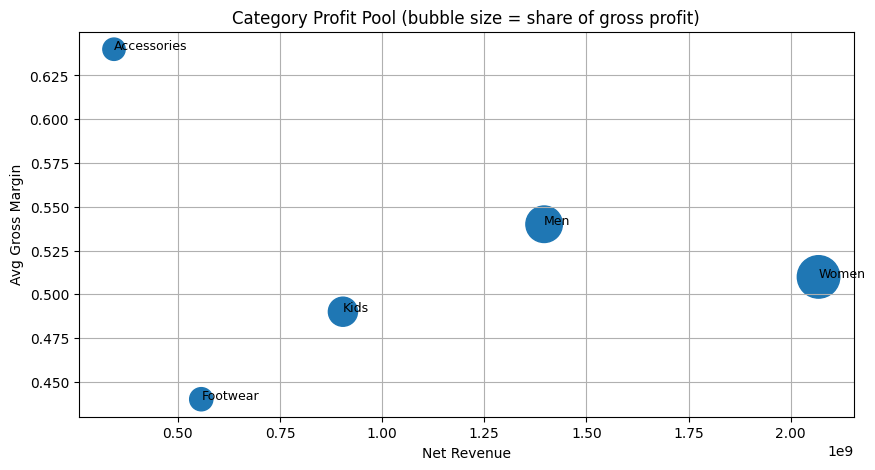

,Category,Net_Revenue,Revenue_Share,Gross_Profit,Profit_Share,Gross_Margin,Avg_Discount
4,Women,2.067960e+09,0.392421,1.054552e+09,0.388120,0.509927,0.049180
3,Men,1.396446e+09,0.264993,7.541525e+08,0.277560,0.540011,0.049073
2,Kids,9.040760e+08,0.171560,4.430177e+08,0.163049,0.490041,0.049212
1,Footwear,5.573879e+08,0.105771,2.452492e+08,0.090262,0.440044,0.049221
0,Accessories,3.438762e+08,0.065255,2.201049e+08,0.081008,0.640002,0.049238


In [11]:
cat = (scope_df("pakistan")
       .groupby("Category", as_index=False)
       .agg(Net_Revenue=("Net_Revenue","sum"),
            Gross_Profit=("Gross_Profit","sum"),
            Gross_Margin=("Gross_Margin","mean"),
            Avg_Discount=("Discount_Pct","mean"),
            Units=("Units","sum")))

cat["Profit_Share"] = cat["Gross_Profit"] / cat["Gross_Profit"].sum()
cat["Revenue_Share"] = cat["Net_Revenue"] / cat["Net_Revenue"].sum()

plt.figure(figsize=(10,5))
plt.scatter(cat["Net_Revenue"], cat["Gross_Margin"], s=cat["Profit_Share"]*2200 + 80)

for _, r in cat.iterrows():
    plt.text(r["Net_Revenue"], r["Gross_Margin"], r["Category"], fontsize=9)

plt.title("Category Profit Pool (bubble size = share of gross profit)")
plt.xlabel("Net Revenue"); plt.ylabel("Avg Gross Margin")
plt.grid(True)
plt.show()
cat.sort_values("Gross_Profit", ascending=False)[
    ["Category","Net_Revenue","Revenue_Share","Gross_Profit","Profit_Share","Gross_Margin","Avg_Discount"]
]


In [12]:
rev_med = cat["Net_Revenue"].median()
gm_med = cat["Gross_Margin"].median()

def bucket(row):
    if row["Net_Revenue"] >= rev_med and row["Gross_Margin"] >= gm_med: return "Grow"
    if row["Net_Revenue"] >= rev_med and row["Gross_Margin"] <  gm_med: return "Fix"
    if row["Net_Revenue"] <  rev_med and row["Gross_Margin"] >= gm_med: return "Test"
    return "Deprioritize"

cat["Bucket"] = cat.apply(bucket, axis=1)
cat[["Category","Bucket","Net_Revenue","Gross_Margin","Profit_Share","Avg_Discount"]].sort_values(["Bucket","Profit_Share"], ascending=[True,False])


,Category,Bucket,Net_Revenue,Gross_Margin,Profit_Share,Avg_Discount
1,Footwear,Deprioritize,5.573879e+08,0.440044,0.090262,0.049221
2,Kids,Fix,9.040760e+08,0.490041,0.163049,0.049212
4,Women,Grow,2.067960e+09,0.509927,0.388120,0.049180
3,Men,Grow,1.396446e+09,0.540011,0.277560,0.049073
0,Accessories,Test,3.438762e+08,0.640002,0.081008,0.049238
